In [69]:
#Set up

#install libraries
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from tueplots import bundles
from tueplots.constants.color import rgb
from tueplots.constants.color.palettes import paultol_vibrant 

# set plotting stylesheet
plt.rcParams.update(bundles.icml2024(column='half', nrows=1, ncols=1)) #test different rows and columns

import sys
print(sys.executable)

#set source and output paths
source_path = '../../data/'
csv_output_path = '../../data/processed/'
figure_output_path = '../../paper/figures/'

#upload raw query data
df_32_raw = pd.read_csv(f'{source_path}repository_queries/500000_32_homicide-female_DE.csv') 
#upload manually tagged articles with json data
df_tag = pd.read_csv(f'{source_path}processed/manual-tag_all_parsedson.csv')
#filter to only ones with T/F data
df_tag_valid = df_tag.dropna(subset=['woman_murdered'])
#upload keyword data
df_key = pd.read_csv(f'{source_path}manual_tag/femicide_keywords.csv')
#upload top k data
df_50 = pd.read_csv(f'{source_path}processed/7-9_22_24_26-27_31-32_2017-2023_top50.csv')
df_25 = pd.read_csv(f'{source_path}processed/7-14_22-24_26-27_29-32_2017-2023_top25.csv')

/Users/madelinemiller/Desktop/data_literacy/geonews_femicide/source/.venv/bin/python


In [63]:
#filters for raw data
#data filtered to only one entry per NUTS and date between 2017 -2023
df_32_raw['NUTS'] = df_32_raw['NUTS'].fillna('').astype(str)
print(f'df 32 raw  shape: {df_32_raw.shape}')
df_32 = df_32_raw.groupby('id').agg({
    'NUTS': lambda x: ', '.join(sorted(set(code for code in x if code.startswith('DE')))),
    'url': 'first',
    'hostname': 'first',
    'date': 'first',
    'cos_dist': 'first', # these values will all be the same
    'hashed_id': 'first',
    'date_crawled': 'first'
    }).reset_index()
#remove null NUTS
df_32 = df_32[df_32['NUTS'].notna()]
df_32 = df_32[df_32['NUTS']!='']

print(f'df 32 nuts condensed shape: {df_32.shape}')
#Convert the date column to datetime objects
df_32['date'] = pd.to_datetime(df_32['date'])      
# Filter for dates
df_32 = df_32[(df_32['date'].dt.year >= 2017) & (df_32['date'].dt.year <= 2023)]
print(f'df 32 date removed shape: {df_32.shape}')
df_32 = df_32[df_32['cos_dist']<=.225].copy()
print(f'shape of df_32 with threshold: {df_32.shape}')

final = pd.read_csv(f'{source_path}final_dataset_t225.csv')

df 32 raw  shape: (1143913, 13)
df 32 nuts condensed shape: (375215, 8)
df 32 date removed shape: (364570, 8)
shape of df_32 with threshold: (31368, 8)


In [3]:
#remove keywords that are too short
df_key = df_key[df_key['category'] != 'remove']

direct_keys = df_key[df_key['query_Direct'] == True]['keyword'].tolist()

all_keys = df_key['keyword'].tolist()

In [76]:
df_tag_valid_final = df_tag_valid[df_tag_valid['id'].isin(final['id'])].copy()


# Check if articles contain query keywords (with whitespace handling)
df_tag_valid_final['contains_query_keyword'] = df_tag_valid_final['found_keywords'].apply(
    lambda x: any(keyword.strip() in [k.strip() for k in str(x).split(',')] 
                  for keyword in direct_keys) if pd.notna(x) else False
)

# Count relevant articles containing query keywords
relevant_dk = df_tag_valid_final[
    (df_tag_valid_final['woman_murdered'] == True) & 
    (df_tag_valid_final['contains_query_keyword'] == True)
].shape[0]

# Count irrelevant articles containing query keywords
irrelevant_dk = df_tag_valid_final[
    (df_tag_valid_final['woman_murdered'] == False) & 
    (df_tag_valid_final['contains_query_keyword'] == True)
].shape[0]

# Count relevant articles not containing query keywords
relevant_without_dk = df_tag_valid_final[
    (df_tag_valid_final['woman_murdered'] == True) & 
    (df_tag_valid_final['contains_query_keyword'] == False)
].shape[0]

# Count irrelevant articles not containing query keywords
irrelevant_without_dk = df_tag_valid_final[
    (df_tag_valid_final['woman_murdered'] == False) & 
    (df_tag_valid_final['contains_query_keyword'] == False)
].shape[0]

total_relevant = df_tag_valid_final[
    (df_tag_valid_final['woman_murdered'] == True)
].shape[0]

total_irrelevant = df_tag_valid_final[
    (df_tag_valid_final['woman_murdered'] == False)
].shape[0]

print(total_relevant)

print(f"Relevant articles with query keywords: {relevant_dk}, {round(relevant_dk/total_relevant * 100,2)}% of relevant")
print(f"Relevant articles without query keywords: {relevant_without_dk}, {round(relevant_without_dk/total_relevant * 100,2)}% of relevant")
print(f"Irrelevant articles with query keywords: {irrelevant_dk}, {round(irrelevant_dk/total_irrelevant * 100,2)}% of irrelevant")
print(f"Irrelevant articles without query keywords: {irrelevant_without_dk}, {round(irrelevant_without_dk/total_irrelevant * 100,2)}% of irrelevant")

475
Relevant articles with query keywords: 170, 35.79% of relevant
Relevant articles without query keywords: 305, 64.21% of relevant
Irrelevant articles with query keywords: 28, 38.89% of irrelevant
Irrelevant articles without query keywords: 44, 61.11% of irrelevant


In [74]:
df_tag_valid_final = df_tag_valid[df_tag_valid['id'].isin(final['id'])].copy()


print(df_tag_valid_final.shape)

# Check if articles contain query keywords (with whitespace handling)
df_tag_valid_final['contains_any_keyword'] = df_tag_valid_final['found_keywords'].apply(
    lambda x: any(keyword.strip() in [k.strip() for k in str(x).split(',')] 
                  for keyword in all_keys) if pd.notna(x) else False
)

# Count relevant articles containing query keywords
relevant_with_keywords = df_tag_valid_final[
    (df_tag_valid_final['woman_murdered'] == True) & 
    (df_tag_valid_final['contains_any_keyword'] == True)
].shape[0]

# Count irrelevant articles containing query keywords
irrelevant_with_keywords = df_tag_valid_final[
    (df_tag_valid_final['woman_murdered'] == False) & 
    (df_tag_valid_final['contains_any_keyword'] == True)
].shape[0]

# Count relevant articles not containing query keywords
relevant_without_keywords = df_tag_valid_final[
    (df_tag_valid_final['woman_murdered'] == True) & 
    (df_tag_valid_final['contains_any_keyword'] == False)
].shape[0]

# Count irrelevant articles not containing query keywords
irrelevant_without_keywords = df_tag_valid_final[
    (df_tag_valid_final['woman_murdered'] == False) & 
    (df_tag_valid_final['contains_any_keyword'] == False)
].shape[0]

total_relevant = df_tag_valid_final[
    (df_tag_valid['woman_murdered'] == True)
].shape[0]

print(total_relevant)

print(f"Relevant articles with  keywords: {relevant_with_keywords}, {round(relevant_with_keywords/total_relevant * 100,2)}% of relevant")
print(f"Relevant articles without  keywords: {relevant_without_keywords}, {round(relevant_without_keywords/total_relevant * 100,2)}% of relevant")
print(f"Irrelevant articles with  keywords: {irrelevant_with_keywords}, {round(irrelevant_with_keywords/total_irrelevant * 100,2)}% of irrelevant")
print(f"Irrelevant articles without  keywords: {irrelevant_without_keywords}, {round(irrelevant_without_keywords/total_irrelevant * 100,2)}% of irrelevant")

(547, 20)
475
Relevant articles with  keywords: 278, 58.53% of relevant
Relevant articles without  keywords: 197, 41.47% of relevant
Irrelevant articles with  keywords: 40, 10.53% of irrelevant
Irrelevant articles without  keywords: 32, 8.42% of irrelevant


/var/folders/8y/qtlvpscd259873sjdt05kvlm0000gn/T/ipykernel_14050/3693374773.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  total_relevant = df_tag_valid_final[


In [57]:
total_dk = relevant_dk + irrelevant_dk
total_without_dk = relevant_without_dk + irrelevant_without_dk

print('relevant')
p_r_given_dk = relevant_dk / total_dk
print(p_r_given_dk)

p_r_given_nodK = relevant_without_dk / total_without_dk
print(p_r_given_nodK)

print('irrelevant')

p_i_given_dk = irrelevant_dk / total_with_keywords
print(p_i_given_dk)

p_i_given_nodK = irrelevant_without_dk / total_dk
print(p_i_given_nodK)

relevant
0.6564102564102564
0.6327800829875518
irrelevant
0.18611111111111112
0.9076923076923077


In [53]:
total_with_keywords = relevant_with_keywords + irrelevant_with_keywords
p_r_given_k = relevant_with_keywords / total_with_keywords
print(p_r_given_k)

total_without_keywords = relevant_without_keywords + irrelevant_without_keywords
p_r_given_noK = relevant_without_keywords / total_without_keywords
print(p_r_given_noK)

p_i_given_k = irrelevant_with_keywords / total_with_keywords
print(p_i_given_k)

total_without_keywords = relevant_without_keywords + irrelevant_without_keywords
p_i_given_noK = irrelevant_without_keywords / total_without_keywords
print(p_i_given_noK)

0.6388888888888888
0.6403785488958991
0.3611111111111111
0.35962145110410093


/var/folders/8y/qtlvpscd259873sjdt05kvlm0000gn/T/ipykernel_14050/2618565133.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


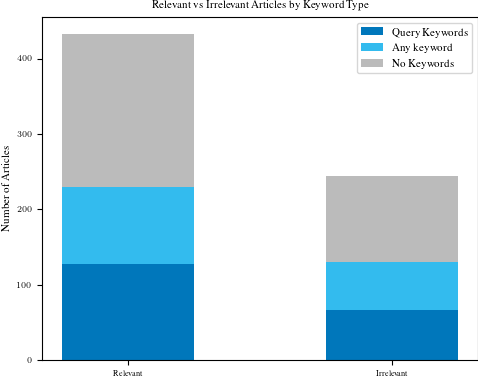

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
# Calculate counts for relevant articles 
relevant_query_kw = relevant_dk 
relevant_other_kw = relevant_with_keywords - relevant_dk 
# Has keywords but not query keywords 
relevant_no_kw = relevant_without_keywords 
# Calculate counts for irrelevant articles 
irrelevant_query_kw = irrelevant_dk 
irrelevant_other_kw = irrelevant_with_keywords - irrelevant_dk 
irrelevant_no_kw = irrelevant_without_keywords

categories = ['Relevant', 'Irrelevant']
query_kw = [relevant_query_kw, irrelevant_query_kw]
other_kw = [relevant_other_kw, irrelevant_other_kw]
no_kw = [relevant_no_kw, irrelevant_no_kw]

x = np.arange(len(categories))
width = 0.5  # make bars wider so they touch nicely

colors = ['#' + c for c in paultol_vibrant]

fig, ax = plt.subplots(figsize=(5, 4))

# Stacked bars
ax.bar(x, query_kw, width, label='Query Keywords', color=colors[0])
ax.bar(x, other_kw, width, bottom=query_kw, label='Any keyword', color=colors[1])
ax.bar(x, no_kw, width, bottom=np.array(query_kw) + np.array(other_kw), label='No Keywords', color=colors[6])

ax.set_ylabel('Number of Articles')
ax.set_title('Relevant vs Irrelevant Articles by Keyword Type')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='upper right', fontsize=8)

# Add value labels inside bars

plt.tight_layout()
plt.show()


In [24]:
import pandas as pd

data = {
    'Category': ['Query Keywords', 'Any Keywords', 'No Keywords', 'Total'],
    'Relevant (n)': [relevant_query_kw, relevant_other_kw, relevant_no_kw, total_relevant],
    'Relevant (%)': [
        f'{relevant_query_kw/total_relevant*100:.1f}',
        f'{relevant_other_kw/total_relevant*100:.1f}',
        f'{relevant_no_kw/total_relevant*100:.1f}',
        '100.0'
    ],
    'Irrelevant (n)': [irrelevant_query_kw, irrelevant_other_kw, irrelevant_no_kw, total_irrelevant],
    'Irrelevant (%)': [
        f'{irrelevant_query_kw/total_irrelevant*100:.1f}',
        f'{irrelevant_other_kw/total_irrelevant*100:.1f}',
        f'{irrelevant_no_kw/total_irrelevant*100:.1f}',
        '100.0'
    ]
}

df_summary = pd.DataFrame(data)

# Export to LaTeX with nice formatting
latex_table = df_summary.to_latex(
    index=False,
    caption='Article Distribution by Keyword Type and Relevance',
    label='tab:keyword_distribution',
    position='htbp',
    column_format='lrrrr'
)

print(latex_table)

\begin{table}[htbp]
\caption{Article Distribution by Keyword Type and Relevance}
\label{tab:keyword_distribution}
\begin{tabular}{lrrrr}
\toprule
Category & Relevant (n) & Relevant (%) & Irrelevant (n) & Irrelevant (%) \\
\midrule
Query Keywords & 128 & 29.6 & 67 & 27.5 \\
Any Keywords & 102 & 23.6 & 63 & 25.8 \\
No Keywords & 203 & 46.9 & 114 & 46.7 \\
Total & 433 & 100.0 & 244 & 100.0 \\
\bottomrule
\end{tabular}
\end{table}

